# SNP array for QC

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import seaborn.objects as so
from scipy.stats import spearmanr, pearsonr

custom_params = {"axes.spines.right": False, "axes.spines.top": False, "axes.edgecolor": "k"}

sns.set_theme(
    context="notebook",
    style="ticks", 
    palette="colorblind",
    font_scale=1.1,
    rc=custom_params
)

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../figures/svg")

In [19]:
chr1toX = ["chr1", "chr2", "chr3", "chr4", "chr5", "chr6", "chr7", "chr8", "chr9", "chr10", "chr11", "chr12", "chr13", "chr14", "chr15", "chr16", "chr17", "chr18", "chr19", "chr20", "chr21", "chr22", "chrX"]
chr1toXhs = list(map(str, range(1, 23))) + ["X"]
samples = pd.read_csv("../sample_info.tsv", sep="\t") 
samples["Type"] = samples["IsSingleCell"].replace({True: "Single cell", False: "Bulk"})
samples["Cell"] = "#" + samples["User ID"].str.split("_").str[-1]
# Remove for bulk samples
samples["Cell"] = samples["Cell"].str.replace("#cells", "")

human_samples = samples.query("Genome == 'Human'")
human_samples

,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type,Cell
0,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,#01
1,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell,#02
2,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell,#03
3,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell,#04
4,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell,#05
5,P33410_1006,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell,#06
7,P33410_1008,Q_A3_cell_07,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#07),Single cell,#07
8,P33410_1009,Q_B3_cell_08,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#08),Single cell,#08
9,P33410_1010,Q_C3_cell_09,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#09),Single cell,#09
10,P33410_1011,Q_D3_cell_10,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#10),Single cell,#10


## Call rate

/Users/pontus.hojer/miniconda3/envs/aviti/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


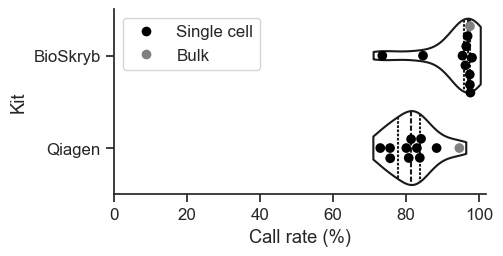

In [3]:
folder = Path("../data/ArrayGenotyping_snpseq01253/files/XK-4162_250519_ResultReport/XK-4162_250519_ResultReport_ICF_PLUS")
d = pd.read_csv(folder / "XK-4162_250519_GenotypingStatistics_ICF_PLUS.csv")
d["User ID"] = d["Individual"]
d = d.merge(samples, on="User ID")
d

fig, ax = plt.subplots(figsize=(4.8, 2.4))
ax = sns.swarmplot(d, x="Call rate per individual (%)", y="Kit", hue="Type", palette=["black", "grey"], edgecolor="k", s=7)
ax = sns.violinplot(d, x="Call rate per individual (%)", y="Kit", inner="quart", fill=None, cut=0.5, density_norm="width", ax=ax, color="k")
ax.set_xlim(left=0)
ax.set_xlabel("Call rate (%)")
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
plt.savefig(figdir / "array_call_rate.svg", dpi=300, bbox_inches="tight", transparent=True)

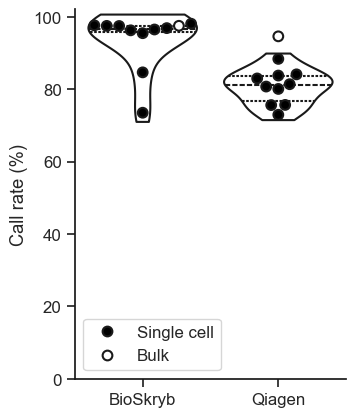

In [79]:
folder = Path("../data/ArrayGenotyping_snpseq01253/files/XK-4162_250519_ResultReport/XK-4162_250519_ResultReport_ICF_PLUS")
d = pd.read_csv(folder / "XK-4162_250519_GenotypingStatistics_ICF_PLUS.csv")
d["User ID"] = d["Individual"]
d = d.merge(samples, on="User ID")
d

fig, ax = plt.subplots(figsize=(3.5, 4.8))
ax = sns.swarmplot(d, y="Call rate per individual (%)", x="Kit", hue="Type", palette=["black", "white"], linewidth=1.5, edgecolor="k", s=7)
ax = sns.violinplot(d.query("Type == 'Single cell'"), y="Call rate per individual (%)", x="Kit", inner="quart", fill=None, cut=0.5, density_norm="width", ax=ax, color="k")
ax.set_ylim(bottom=0)
ax.set_ylabel("Call rate (%)")
ax.set_xlabel("")
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
plt.savefig(figdir / "array_call_rate_v.svg", dpi=300, bbox_inches="tight", transparent=True)

In [5]:
d.groupby(["Kit", "Type"])["Call rate per individual (%)"].agg(["median", "mean", "min", "max"])

median    mean    min    max
Kit      Type                                     
BioSkryb Bulk         97.500  97.500  97.50  97.50
         Single cell  96.670  93.381  73.49  98.07
Qiagen   Bulk         94.590  94.590  94.59  94.59
         Single cell  81.045  80.550  72.93  88.36

In [6]:
d[["SampleName", "Call rate per individual (%)"]].set_index("SampleName")\
    .style.background_gradient(axis=None, vmin=80, vmax=100, cmap="YlGnBu")

,Call rate per individual (%)
SampleName,
BioSkryb (Cell#03),97.450000
BioSkryb (Cell#04),95.460000
BioSkryb (Cell#05),97.480000
BioSkryb (Cell#01),98.070000
BioSkryb (Cell#02),96.860000
BioSkryb (Cell#06),96.250000
BioSkryb (Cell#07),73.490000
BioSkryb (Cell#08),84.640000
BioSkryb (Cell#09),97.630000


## Log-ratio for coverage evenness

https://www.illumina.com/Documents/products/technotes/technote_cytoanalysis.pdf

For each SNP is reported a log-ratio for the spot intensity values (log2(R_obs/R_exp)).

The mean of this log-ratio have been calculated in 100kb bins

In [4]:
def mad(x):
    # Median absolute deviation
    return np.abs(x - x.median()).median()

def mapd(data, cov_col="cov"):
    # Median absolute pairwise deviation
    dev = []

    # Find binsize
    binsize = data.iloc[0,:]["end"] - data.iloc[0,:]["start"]
    for c, cdata in data.groupby("contig"):
        x = cdata["cov"].values
        
        # Calculate deviation between adjacent bins
        deviation = x[:-1] - x[1:]

        # Find gaps
        gaps = (cdata["start"].values[1:] - cdata["start"].values[:-1]) > binsize
        # Remove gaps
        deviation = deviation[~gaps]
        dev.append(deviation)

    # Calculate median absolute pairwise deviation
    return np.median(np.abs(np.concatenate(dev)))


In [41]:
basedir = Path("../analysis/array_qc/bedgraph_100kb")
rdir = Path("../analysis/downsample_qc/downstream_qc/mosdepth_100kb")
assert basedir.exists()

cov = []
for file in basedir.rglob("*.bedgraph"):
    sample = file.stem.split(".")[0]
    d = pd.read_csv(file, sep="\t", header=0, names=["contig", "start", "end", "cov"])
    d = d[d["contig"].isin(chr1toX) & (d["cov"] != ".")]
    d["cov"] = d["cov"].astype(float)

    # Reads coverage
    ngi_id = samples.query("`User ID` == @sample")["NGI ID"].values[0]
    rbedg = rdir / f"{ngi_id}.regions.bed.gz"
    d1 = pd.read_csv(rbedg, sep="\t", header=None, names=["contig", "start", "end", "cov"])
    d1 = d1[d1["contig"].isin(chr1toX)]
    d1["cov"] = np.log2(d1["cov"]/d1["cov"].median()+0.001) # Convert to log2 ratio w. epsilon to avoid log2(0)

    cov.append({
        "User ID": sample,
        "mad_arr": mad(d["cov"]),
        "mapd_arr": mapd(d),
        "mad_reads": mad(d1["cov"]),
        "mapd_reads": mapd(d1),
    })


cov = pd.DataFrame(cov)
cov = cov.merge(samples, on="User ID")
cov = cov.sort_values("Kit", ascending=False)
cov

,User ID,mad_arr,mapd_arr,mad_reads,mapd_reads,NGI ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type,Cell
11,Q_G2_cell_06,0.675677,0.540425,1.179306,0.953955,P33410_1006,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell,#06
1,Q_C3_cell_09,0.480937,0.427092,0.978649,0.777592,P33410_1010,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#09),Single cell,#09
18,Q_D2_cell_03,0.653875,0.589406,1.118439,0.974998,P33410_1003,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell,#03
17,Q_F2_cell_05,0.508517,0.517604,0.948198,0.908467,P33410_1005,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell,#05
16,Q_D3_cell_10,0.667192,0.610607,1.131804,1.043415,P33410_1011,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#10),Single cell,#10
15,Q_B3_cell_08,0.340004,0.383020,0.742747,0.716671,P33410_1009,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#08),Single cell,#08
13,Q_A3_cell_07,0.483067,0.517110,0.888778,0.861355,P33410_1008,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#07),Single cell,#07
21,Q_H3_10_cells,0.153951,0.151704,0.430220,0.346610,P33410_1012,False,Qiagen,MM1S cell line,Human,Qiagen (Bulk),Bulk,
6,Q_E2_cell_04,0.516858,0.554637,0.878087,0.882629,P33410_1004,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell,#04
5,Q_B2_cell_01,0.459554,0.499810,0.873715,0.857575,P33410_1001,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,#01


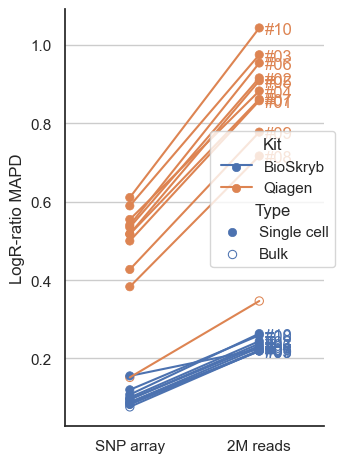

In [80]:
cols = [
    #'mad_arr', 
    'mapd_arr', 
    #'mad_reads', 
    'mapd_reads', 
]
d = cov.melt(
    id_vars=["Kit", "Type", "SampleName", "Cell"], 
    value_vars=cols,
)
d = d.sort_values("SampleName", ascending=False)
d["ShortName"] = d["SampleName"].str[-4:-1]
d[["metric", "data"]] = d["variable"].str.split("_", expand=True)
d["data"] = d["data"].replace({
    "reads": "2M reads",
    "arr": "SNP array"
})

p = (
    so.Plot(d, x="data", y="value", color="Kit", group="SampleName", text="Cell")
    .share(x=False)
    .add(so.Dot(), fill="Type")
    .add(so.Path())
    .add(so.Text(halign="left"), data=d.query("data == '2M reads'"))
    .label(x="", y="LogR-ratio MAPD")
    .scale(
        color=so.Nominal(order=["BioSkryb", "Qiagen"]),
    )
    .layout(engine="tight", size=(3.5, 4.8))
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .save(figdir / "array_mapd_vs_2M_reads.svg", dpi=300, bbox_inches="tight", transparent=True)
)
p.show()

## Log-ratio vs 2M read coverage correlation

In [84]:
data = []
basedir = Path("../analysis/array_qc/bedgraph_100kb")
rdir = Path("../analysis/downsample_qc/downstream_qc/mosdepth_100kb")
assert basedir.exists()
assert rdir.exists()
for file in basedir.rglob("*.bedgraph"):
    sample = file.stem.split(".")[0]
    d = pd.read_csv(file, sep="\t", header=None, names=["contig", "start", "end", "arr_logr"])
    d["User ID"] = sample
    ngi_id = samples.query("`User ID` == @sample")["NGI ID"].values[0]

    d = d[d["contig"].isin(chr1toX)]
    d["arr_logr"] = d["arr_logr"].replace({'.': np.nan})
    d["arr_logr"] = d["arr_logr"].astype(float)

    rbedg = rdir / f"{ngi_id}.regions.bed.gz"

    d2 = pd.read_csv(rbedg, sep="\t", header=None, names=["contig", "start", "end", "read_cov"])
    d = d.merge(d2, on=["contig", "start", "end"])
    d["read_logr"] = np.log2(d["read_cov"] / d["read_cov"].median())  
    data.append(d)

data = pd.concat(data).reset_index(drop=True)
data = data.merge(samples, on="User ID")
data.head()


/Users/pontus.hojer/miniconda3/envs/scwgs/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pontus.hojer/miniconda3/envs/scwgs/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pontus.hojer/miniconda3/envs/scwgs/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pontus.hojer/miniconda3/envs/scwgs/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/pontus.hojer/miniconda3/envs/scwgs/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, me

,contig,start,end,arr_logr,User ID,read_cov,read_logr,NGI ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type,Cell
0,chr1,0,100000,NaN,B_A4_cell_02,0.13410,-0.406134,P33410_1014,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#02),Single cell,#02
1,chr1,100000,200000,NaN,B_A4_cell_02,0.05670,-1.648023,P33410_1014,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#02),Single cell,#02
2,chr1,200000,300000,NaN,B_A4_cell_02,0.03936,-2.174642,P33410_1014,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#02),Single cell,#02
3,chr1,300000,400000,NaN,B_A4_cell_02,0.00298,-5.897988,P33410_1014,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#02),Single cell,#02
4,chr1,400000,500000,NaN,B_A4_cell_02,0.01208,-3.878751,P33410_1014,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#02),Single cell,#02


In [85]:

corrs = []

for s, d in data.groupby("SampleName"):
    d = d[(~d["arr_logr"].isna()) & (~d["read_logr"].isna()) & (~np.isinf(d["read_logr"]))]
    corr = spearmanr(d["arr_logr"], d["read_logr"]).correlation
    pcorr = pearsonr(d["arr_logr"], d["read_logr"])[0]
    corrs.append({
        "SampleName": s,
        "Spearman": corr,
        "Pearson": pcorr
    })

corrs = pd.DataFrame(corrs)
corrs = corrs.merge(samples, on="SampleName")
corrs[["SampleName", "Spearman", "Pearson"]].set_index("SampleName")\
    .style.background_gradient(axis=None, vmax=1,  vmin=0.7, cmap="YlGnBu").format(precision=2)


,Spearman,Pearson
SampleName,,
BioSkryb (Bulk),0.80,0.81
BioSkryb (Cell#01),0.79,0.80
BioSkryb (Cell#02),0.82,0.82
BioSkryb (Cell#03),0.77,0.79
BioSkryb (Cell#04),0.84,0.88
BioSkryb (Cell#05),0.73,0.77
BioSkryb (Cell#06),0.79,0.83
BioSkryb (Cell#07),0.91,0.96
BioSkryb (Cell#08),0.91,0.95


In [92]:
corrs["Pearson"].mean()

np.float64(0.8297270702578231)

In [87]:
corrs

,SampleName,Spearman,Pearson,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,Type,Cell
0,BioSkryb (Bulk),0.800911,0.814720,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,Bulk,
1,BioSkryb (Cell#01),0.786784,0.801781,P33410_1013,B_A3_cell_01,True,BioSkryb,MM1S cell line,Human,Single cell,#01
2,BioSkryb (Cell#02),0.820351,0.816214,P33410_1014,B_A4_cell_02,True,BioSkryb,MM1S cell line,Human,Single cell,#02
3,BioSkryb (Cell#03),0.772610,0.788901,P33410_1015,B_B1_cell_03,True,BioSkryb,MM1S cell line,Human,Single cell,#03
4,BioSkryb (Cell#04),0.840861,0.878511,P33410_1016,B_B2_cell_04,True,BioSkryb,MM1S cell line,Human,Single cell,#04
5,BioSkryb (Cell#05),0.725120,0.774152,P33410_1017,B_B3_cell_05,True,BioSkryb,MM1S cell line,Human,Single cell,#05
6,BioSkryb (Cell#06),0.785255,0.829502,P33410_1018,B_B4_cell_06,True,BioSkryb,MM1S cell line,Human,Single cell,#06
7,BioSkryb (Cell#07),0.907028,0.958476,P33410_1019,B_C1_cell_07,True,BioSkryb,MM1S cell line,Human,Single cell,#07
8,BioSkryb (Cell#08),0.914361,0.949737,P33410_1020,B_C2_cell_08,True,BioSkryb,MM1S cell line,Human,Single cell,#08
9,BioSkryb (Cell#09),0.755894,0.788122,P33410_1021,B_C3_cell_09,True,BioSkryb,MM1S cell line,Human,Single cell,#09


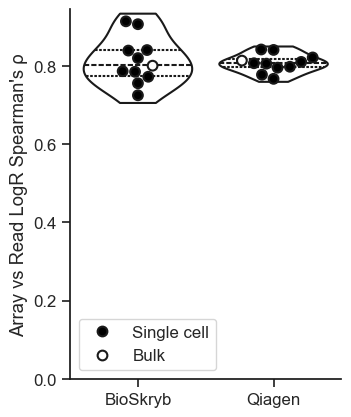

In [88]:
fig, ax = plt.subplots(figsize=(3.5, 4.8))

ax = sns.swarmplot(corrs.sort_values("Type", ascending=False), y="Spearman", order=["BioSkryb", "Qiagen"], x="Kit", hue="Type", palette=["black", "white"], linewidth=1.5, edgecolor="k", s=7)
ax = sns.violinplot(corrs.query("Type == 'Single cell'"), y="Spearman", x="Kit", inner="quart", fill=None, cut=0.5, density_norm="width", ax=ax, color="k")
ax.set_ylim(bottom=0)
ax.set_ylabel("Array vs Read LogR Spearman's ρ")
ax.set_xlabel("")
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
plt.savefig(figdir / "array_spearman.svg", dpi=300, bbox_inches="tight", transparent=True)

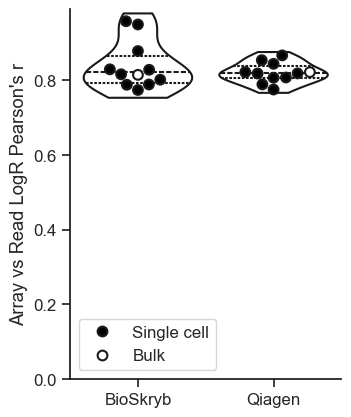

In [91]:
fig, ax = plt.subplots(figsize=(3.5, 4.8))

ax = sns.swarmplot(corrs.sort_values("Type", ascending=False), y="Pearson", order=["BioSkryb", "Qiagen"], x="Kit", hue="Type", palette=["black", "white"], linewidth=1.5, edgecolor="k", s=7)
ax = sns.violinplot(corrs.query("Type == 'Single cell'"), y="Pearson", x="Kit", inner="quart", fill=None, cut=0.5, density_norm="width", ax=ax, color="k")
ax.set_ylim(bottom=0)
ax.set_ylabel("Array vs Read LogR Pearson's r")
ax.set_xlabel("")
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
plt.savefig(figdir / "array_pearson.svg", dpi=300, bbox_inches="tight", transparent=True)

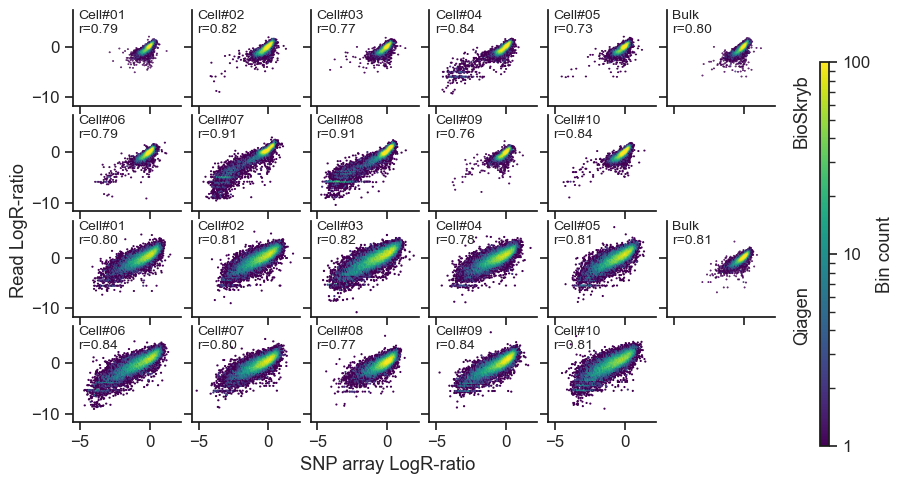

In [78]:

order = [
    'BioSkryb (Cell#01)',
    'BioSkryb (Cell#02)',
    'BioSkryb (Cell#03)',
    'BioSkryb (Cell#04)',
    'BioSkryb (Cell#05)',
    'BioSkryb (Bulk)',
    'BioSkryb (Cell#06)',
    'BioSkryb (Cell#07)',
    'BioSkryb (Cell#08)',
    'BioSkryb (Cell#09)',
    'BioSkryb (Cell#10)',
    None,
    'Qiagen (Cell#01)',
    'Qiagen (Cell#02)',
    'Qiagen (Cell#03)',
    'Qiagen (Cell#04)',
    'Qiagen (Cell#05)',
    'Qiagen (Bulk)',
    'Qiagen (Cell#06)',
    'Qiagen (Cell#07)',
    'Qiagen (Cell#08)',
    'Qiagen (Cell#09)',
    'Qiagen (Cell#10)',
    None
]

fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(9,4.8), sharex=True, sharey=True)
corrs = []
for ax, s in zip(axes.ravel(), order):
    if s is None:
        ax.axis("off")
        continue

    d = data.query("`SampleName` == @s")
    d = d[(~d["arr_logr"].isna()) & (~d["read_logr"].isna()) & (~np.isinf(d["read_logr"]))]
    corr = spearmanr(d["arr_logr"], d["read_logr"]).correlation    

    corrs.append(corr)
    hb = ax.hexbin(d["arr_logr"], d["read_logr"], gridsize=100, cmap='viridis', bins='log', vmin=1, vmax=100, rasterized=True)
    
    name = s.split("(")[-1].split(")")[0]
    #ax.text(0.05, 1, f"{name}\nρ={corr:.2f}", transform=ax.transAxes, va="top", fontsize=10)
    ax.text(0.05, 1, f"{name}\nr={corr:.2f}", transform=ax.transAxes, va="top", fontsize=10)

fig.text(0.08, 0.5, "Read LogR-ratio", rotation=90, va="center")
fig.text(0.95, 0.68, "BioSkryb", ha="left", rotation=90)
fig.text(0.95, 0.27, "Qiagen", ha="left", rotation=90)
fig.text(0.5, 0, "SNP array LogR-ratio", ha="center")
plt.tight_layout()
fig.subplots_adjust(hspace=0.1, wspace=0.1, left=0.15, right=0.93)
cbar_ax = fig.add_axes([0.98, 0.05, 0.01, 0.8])
fig.colorbar(hb, cax=cbar_ax, label="Bin count", ticks=[1, 10, 100])
cbar_ax.set_yticklabels(['1', '10', '100']) 
fig.savefig(figdir / "array_2M_reads_LRR_correlation.svg", dpi=300, bbox_inches="tight", transparent=True)
fig.savefig(figdir / "array_2M_reads_LRR_correlation.pdf", dpi=300, bbox_inches="tight", transparent=True)


## SNP calls

In [14]:
basedir = Path("../analysis/array_qc")
snps = pd.read_csv(basedir / "samples.rename.gt.tsv.gz", sep="\t")

# Drop empty column
snps = snps.drop(columns=["Unnamed: 23"])

# Rename columns
cols = list(snps.columns)
cols = [c.split("]")[1].split(":")[0] for c in cols]
cols[0] = "loc"
snps.columns = cols
snsp = snps.set_index("loc")
snps.head()

,loc,B_A3_cell_01,B_A4_cell_02,B_B1_cell_03,B_B2_cell_04,B_B3_cell_05,B_B4_cell_06,B_C1_cell_07,B_C2_cell_08,B_C3_cell_09,...,Q_B2_cell_01,Q_B3_cell_08,Q_C2_cell_02,Q_C3_cell_09,Q_D2_cell_03,Q_D3_cell_10,Q_E2_cell_04,Q_F2_cell_05,Q_G2_cell_06,Q_H3_10_cells
0,1:632287,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,...,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0
1,1:632828,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,...,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0
2,1:633147,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,...,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0
3,1:792461,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,...,0/0,0/0,./.,0/0,0/0,./.,0/0,0/0,0/0,0/0
4,1:817341,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,...,0/0,0/0,./.,0/0,./.,0/0,0/0,0/0,0/0,0/0


### Bulk comparison

Lets first check how the bulks compare

In [15]:
# Find positions where either bulk has call
no_call = ['./.', '.']
snpsb = snps.query("B_H3_10_cells not in @no_call or Q_H3_10_cells not in @no_call")

total_pos = snps.shape[0]
total = snpsb.shape[0]
match_bulk = snpsb.query("B_H3_10_cells == Q_H3_10_cells").shape[0]
mismatch_bulk = snpsb.query("B_H3_10_cells != Q_H3_10_cells").shape[0]

print(f"Bulk called positions: {total} ({total/total_pos:.2%}%)")
print(f"Matches: {match_bulk} ({match_bulk/total:.2%}%)")
print(f"Mismatches: {mismatch_bulk} ({mismatch_bulk/total:.2%}%)")


Bulk called positions: 638638 (98.72%%)
Matches: 602083 (94.28%%)
Mismatches: 36555 (5.72%%)


Most genotype match between the two bulk samples par ~5%, lets inspect the mismatches.

In [16]:
d = snpsb.query("B_H3_10_cells != Q_H3_10_cells")

b_no_call = d.query("B_H3_10_cells in @no_call").shape[0]
q_no_call = d.query("Q_H3_10_cells in @no_call").shape[0]

print(f"BioSkryb no call: {b_no_call} ({b_no_call/mismatch_bulk:.2%}%)")
print(f"Qiagen no call: {q_no_call} ({q_no_call/mismatch_bulk:.2%}%)")


BioSkryb no call: 7537 (20.62%%)
Qiagen no call: 26457 (72.38%%)


Majority of mismatches due to missing calls in Qiagen bulk

### Single cell comparison

#### Concordance with bulk called (either)
Look at how genotype compare to those called by either bulk

,SampleName,Kit,Type,n_missing,n_missing_pct
0,Qiagen (Cell#01),Qiagen,Single cell,97216,15.222395
1,Qiagen (Cell#02),Qiagen,Single cell,114691,17.958687
2,Qiagen (Cell#03),Qiagen,Single cell,151433,23.711868
3,Qiagen (Cell#04),Qiagen,Single cell,118873,18.613518
4,Qiagen (Cell#05),Qiagen,Single cell,123165,19.285573
5,Qiagen (Cell#06),Qiagen,Single cell,151199,23.675228
6,Qiagen (Cell#07),Qiagen,Single cell,104401,16.347446
7,Qiagen (Cell#08),Qiagen,Single cell,69510,10.884100
8,Qiagen (Cell#09),Qiagen,Single cell,99287,15.546679
9,Qiagen (Cell#10),Qiagen,Single cell,168919,26.449882


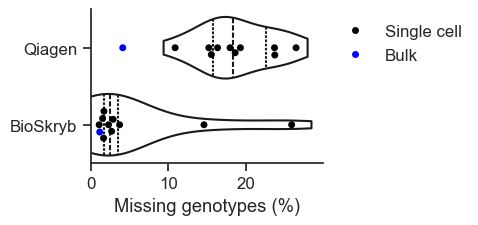

In [17]:
d = []
for _, sample in human_samples.iterrows():
    n_missing = snpsb.query(f"{sample['User ID']} in @no_call").shape[0]
    d.append({
        "SampleName": sample["SampleName"],
        "Kit": sample["Kit"],
        "Type": sample["Type"],
        "n_missing": n_missing,
        "n_missing_pct": 100 * n_missing / total
    })

d = pd.DataFrame(d)
display(d)

fig, ax = plt.subplots(figsize=(3, 2))
ax = sns.violinplot(
    d.query("Type == 'Single cell'"),
    x="n_missing_pct", 
    y="Kit",
    inner="quart", 
    fill=None, 
    legend=False,
    color="k",
    density_norm="width", 
    cut=0.5,
    ax=ax
)
ax = sns.swarmplot(d, x="n_missing_pct", y="Kit", hue="Type", palette=["black", "blue"], edgecolor="k",
)
ax.set_xlabel("Missing genotypes (%)")
ax.set_ylabel("")
ax.set_xlim(left=0)
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1,1))

#### Concordance with bulk called (both)
Compare how single cells compare to genotypes agreed upon by bulk.


,SampleName,Kit,Type,n_missing,n_missing_pct
0,Qiagen (Cell#01),Qiagen,Single cell,85065,13.319752
1,Qiagen (Cell#02),Qiagen,Single cell,101974,15.967418
2,Qiagen (Cell#03),Qiagen,Single cell,137308,21.500130
3,Qiagen (Cell#04),Qiagen,Single cell,106076,16.609723
4,Qiagen (Cell#05),Qiagen,Single cell,110071,17.235273
5,Qiagen (Cell#06),Qiagen,Single cell,136822,21.424031
6,Qiagen (Cell#07),Qiagen,Single cell,91947,14.397358
7,Qiagen (Cell#08),Qiagen,Single cell,57571,9.014653
8,Qiagen (Cell#09),Qiagen,Single cell,87083,13.635737
9,Qiagen (Cell#10),Qiagen,Single cell,154512,24.193988


/var/folders/9f/8ggsf77s7hx0xcdvhzs8pfjx0t5xky/T/ipykernel_59445/3837713222.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1,1))


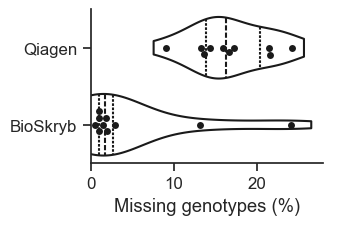

In [18]:
d = []
snpsbm = snpsb.query("B_H3_10_cells == Q_H3_10_cells").copy()
for _, sample in human_samples.iterrows():
    n_missing = snpsbm.query(f"{sample['User ID']} in @no_call").shape[0]
    d.append({
        "SampleName": sample["SampleName"],
        "Kit": sample["Kit"],
        "Type": sample["Type"],
        "n_missing": n_missing,
        "n_missing_pct": 100 * n_missing / total
    })

d = pd.DataFrame(d)
display(d)

fig, ax = plt.subplots(figsize=(3, 2))
ax = sns.violinplot(
    d.query("Type == 'Single cell'"),
    x="n_missing_pct", 
    y="Kit",
    inner="quart", 
    fill=None, 
    legend=False,
    color="k",
    density_norm="width", 
    cut=0.5,
    ax=ax
)
ax = sns.swarmplot(d.query("Type == 'Single cell'"), x="n_missing_pct", y="Kit", color="k")
ax.set_xlabel("Missing genotypes (%)")
ax.set_ylabel("")
ax.set_xlim(left=0)
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1,1))

Higher percentage missing in Qiagen samples as expected

#### Concordance with bulk consensus - All genotypes

602083


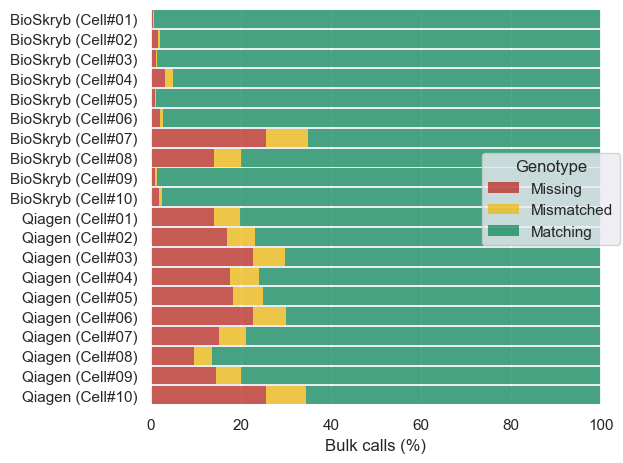

In [19]:
da = []
for kit, group in human_samples.groupby("Kit"):
    bulk_sample = group.query("IsSingleCell == False").iloc[0]
    sc_samples = group.query("IsSingleCell == True")
    
    for _, sample in sc_samples.iterrows():
        n_missing = snpsbm.query(f"{sample['User ID']} in @no_call").shape[0]
        n_mismatch = snpsbm.query(f"{sample['User ID']} != {bulk_sample['User ID']}").shape[0] - n_missing
        n_match = snpsbm.query(f"{sample['User ID']} == {bulk_sample['User ID']}").shape[0]
    
        da.append({
            "SampleName": sample["SampleName"],
            "Kit": kit,
            "n_missing": n_missing,
            "n_missing_pct": 100 * n_missing / len(snpsbm),
            "n_mismatch": n_mismatch,
            "n_mismatch_pct": 100 * n_mismatch / len(snpsbm),
            "n_match": n_match,
            "n_match_pct": 100 * n_match / len(snpsbm),
        })
        assert n_missing + n_match + n_mismatch == len(snpsbm)
print(len(snpsbm))
da = pd.DataFrame(da)
d = da.melt(id_vars=["SampleName", "Kit"], value_vars=["n_missing_pct", "n_mismatch_pct", "n_match_pct"], var_name="Genotype")

d["Genotype"] = d["Genotype"].replace(
    {
        "n_missing_pct": "Missing",
        "n_mismatch_pct": "Mismatched",
        "n_match_pct": "Matching"
    }
)
# Plot stacked bar chart
p = (
    so.Plot(d, y="SampleName", x="value", color="Genotype", group="Kit")
    .add(so.Bar(width=0.9, edgealpha=0), so.Agg(), so.Stack())
    .limit(x=(0,100))
    .label(
        x="Bulk calls (%)",
        y="",
    )
    .scale(color=["#B81D13", "#EFB700", "#008450"])
    .save(figdir / "array_bulk_consensus_genotype_concordance.svg", dpi=300, bbox_inches="tight", transparent=True)
)
p.show()

In [20]:
print(da.to_csv(index=False))

SampleName,Kit,n_missing,n_missing_pct,n_mismatch,n_mismatch_pct,n_match,n_match_pct
BioSkryb (Cell#01),BioSkryb,3747,0.6223394448938103,952,0.15811773459805376,597384,99.21954282050814
BioSkryb (Cell#02),BioSkryb,9527,1.5823399763819939,2803,0.46555043075456376,589753,97.95210959286344
BioSkryb (Cell#03),BioSkryb,6638,1.102505800695253,1673,0.2778686659480504,593772,98.6196255333567
BioSkryb (Cell#04),BioSkryb,18990,3.1540501890935304,10958,1.8200148484511272,572135,95.02593496245534
BioSkryb (Cell#05),BioSkryb,6426,1.067294708536863,1453,0.24132885333085305,594204,98.69137643813228
BioSkryb (Cell#06),BioSkryb,12675,2.105191476922617,3934,0.653398285618428,585474,97.24141023745895
BioSkryb (Cell#07),BioSkryb,153793,25.54348819016647,56615,9.403188596921023,391675,65.0533232129125
BioSkryb (Cell#08),BioSkryb,84164,13.978803586880879,36133,6.001332042259954,481786,80.01986437085917
BioSkryb (Cell#09),BioSkryb,6232,1.035073237410789,2246,0.3730382688101142,593605,98.5918884937791
BioSkry

#### Concordance with bulk consensus - Heterozygous only

Total heterozygous SNPs BioSkryb: 64038
Total heterozygous SNPs Qiagen: 64038


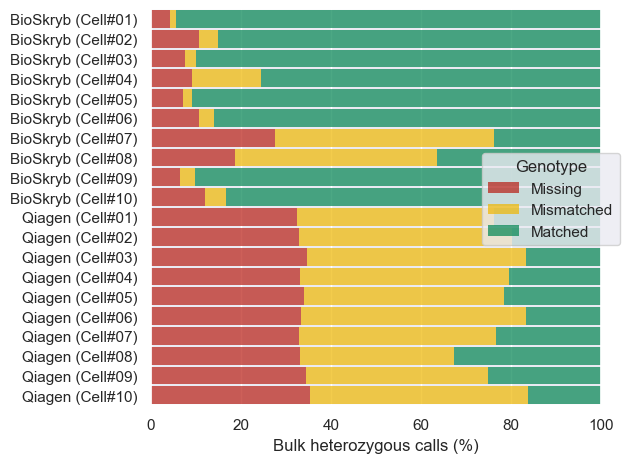

In [21]:
dh = []
for kit, group in human_samples.groupby("Kit"):
    bulk_sample = group.query("IsSingleCell == False").iloc[0]
    sc_samples = group.query("IsSingleCell == True")
    
    snpsk = snps.query(f"{bulk_sample['User ID']} not in @no_call")

    # only heterozygous
    hets = ["0/1", "0/2", "1/2"]
    snpsk = snpsbm.query(f"{bulk_sample['User ID']} in @hets")
    print(f"Total heterozygous SNPs {kit}: {len(snpsk)}")
    for _, sample in sc_samples.iterrows():
        n_missing = snpsk.query(f"{sample['User ID']} in @no_call").shape[0]
        n_mismatch = snpsk.query(f"{sample['User ID']} != {bulk_sample['User ID']}").shape[0] - n_missing
        n_match = snpsk.query(f"{sample['User ID']} == {bulk_sample['User ID']}").shape[0]
    
        dh.append({
            "SampleName": sample["SampleName"],
            "Kit": kit,
            "n_missing": n_missing,
            "n_missing_pct": 100 * n_missing / len(snpsk),
            "n_mismatch": n_mismatch,
            "n_mismatch_pct": 100 * n_mismatch / len(snpsk),
            "n_match": n_match,
            "n_match_pct": 100 * n_match / len(snpsk),
        })
        assert n_missing + n_match + n_mismatch == len(snpsk)

dh = pd.DataFrame(dh)
d = dh.melt(id_vars=["SampleName", "Kit"], value_vars=["n_missing_pct", "n_mismatch_pct", "n_match_pct"], var_name="Genotype")

d["Genotype"] = d["Genotype"].replace(
    {
        "n_missing_pct": "Missing",
        "n_mismatch_pct": "Mismatched",
        "n_match_pct": "Matched"
    }
)
# Plot stacked bar chart
p = (
    so.Plot(d, y="SampleName", x="value", color="Genotype", group="Kit")
    .add(so.Bar(width=0.9, edgealpha=0), so.Agg(), so.Stack())
    .limit(x=(0,100))
    .scale(color=["#B81D13", "#EFB700", "#008450"]) 
    .label(
        x="Bulk heterozygous calls (%)",
        y="",
    )
    .save(figdir / "array_bulk_consensus_genotype_concordance_hets.svg", dpi=300, bbox_inches="tight", transparent=True)
)
p.show()

In [22]:
print(dh.to_csv(index=False))

SampleName,Kit,n_missing,n_missing_pct,n_mismatch,n_mismatch_pct,n_match,n_match_pct
BioSkryb (Cell#01),BioSkryb,2715,4.2396701958212315,914,1.4272775539523408,60409,94.33305225022643
BioSkryb (Cell#02),BioSkryb,6899,10.773290858552734,2656,4.147537399668947,54483,85.07917174177832
BioSkryb (Cell#03),BioSkryb,4887,7.631406352478216,1573,2.4563540397888755,57578,89.91223960773291
BioSkryb (Cell#04),BioSkryb,5878,9.17892501327337,9747,15.22065023892064,48413,75.60042474780599
BioSkryb (Cell#05),BioSkryb,4671,7.294106624191886,1171,1.8286017677004278,58196,90.87729160810768
BioSkryb (Cell#06),BioSkryb,6941,10.838876916830632,2116,3.3042880789531215,54981,85.85683500421625
BioSkryb (Cell#07),BioSkryb,17660,27.577375933039757,31073,48.52275211593117,15305,23.899871951029077
BioSkryb (Cell#08),BioSkryb,11957,18.67172616259096,28673,44.77497735719417,23408,36.553296480214875
BioSkryb (Cell#09),BioSkryb,4172,6.514881788937818,2085,3.2558793216527686,57781,90.22923888940942
BioSkryb (Cell#10),B